# this notebook contains pooled tetramer screen deseq2 analysis, MA plots and validating non-validating definition (tetramer screen)

figures 3, S3

In [ ]:
import pandas as pd
toolbox_path = "/tcr_toolbox/"

ref_df_path = toolbox_path + "tcr_toolbox_tcr_assembly_runs/r3_2023-08-23_any_mers_full_seq_dataset_vdjdb_only/v6/sequencing_quality_analysis/references/tcr_refs_df.csv"
ref_df = pd.read_csv(ref_df_path)
fasta_path = toolbox_path + "tcr_toolbox_tcr_assembly_runs/r3_2023-08-23_any_mers_full_seq_dataset_vdjdb_only/v6/sequencing_quality_analysis/references/stapler_tcr_assembly_nanopore.fa"
fasta_data = {}
with open(fasta_path, "r") as fasta_in: 
    for entry in fasta_in:
        if entry.startswith(">"):
            entry = entry[1:].strip('\n')
            name_entry = entry
            fasta_data[name_entry] = ""
        else:
            fasta_data[name_entry] += entry.strip()

print(len(fasta_data), 'fasta_data')
subset_data = list(fasta_data.keys())

print(len(ref_df) , 'ref_df before')
ref_df_subset = ref_df[ref_df['name'].isin(subset_data)].reset_index(drop=True).copy()
print(len(ref_df_subset) , 'ref_df after')


3693 fasta_data
7680 ref_df before
3693 ref_df after


In [ ]:
from utils import set_mpl_params #,color_df_on_color_loop
import matplotlib as mpl
import matplotlib.font_manager as fm 


out_path_dropbox = ''
SAVE_DROPBOX = True
fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf")
mpl, mylines = set_mpl_params(mpl)
figsize = (5.1/2.54, 4/2.54)
dotsize = 5
fontsize_axes = 7

background_alpha = 0.45
color_alpha = 0.6

In [ ]:
baseline_dict = {
    'baseline_a': '/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_b/concatenated_barcode02_baseline_b/concatenated_barcode02_baseline_b_filtered_umi_count.csv',
    'baseline_b': '/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/seq_data/11_tetramer_sort_june-2025/outs/concatenated_barcode12_baseline_tetramer/concatenated_barcode12_baseline_tetramer_filtered_umi_count.csv',
    'baseline_c': '/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/seq_data/10_stapler_vdjdb_baselines-GIL-LTD_GILpositivesABC-repeat/outs/concatenated_barcode20_baseline_gil/concatenated_barcode20_baseline_gil_filtered_umi_count.csv',
}



In [ ]:
run_dict = [
        {
        'outs_path' : '/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/seq_data/11_tetramer_sort_june-2025/outs',
        'epitope1' : 'GLCTLVAML',
        'epitope2' : 'YLQPRTFLL',
        'baseline' : '/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/seq_data/11_tetramer_sort_june-2025/outs/concatenated_barcode12_baseline_tetramer/concatenated_barcode12_baseline_tetramer_filtered_umi_count.csv',
    }
]

In [5]:
import pandas as pd
colors_dict = {}

color_name_dict = {
    'lightgrey': 'other annotated',
    'crimson': 'GILGFVFTL annotated',      # red
    'cornflowerblue': 'YLQPRTFLL annotated', # blue
    'forestgreen': 'TTDPSFLGRY annotated',   # green
    'darkorange': 'NLVPMVATV annotated',     # orange
    'mediumorchid': 'SPRWYFYYL annotated',   # purple
    'darkturquoise': 'CINGVCWTV annotated',  # turquoise
    'gold': 'LLWNGPMAV annotated',           # yellow
    'indianred': 'GLCTLVAML annotated',        # deep red
    'darkviolet': 'LTDEMIAQY annotated',     # violet
    'teal': 'ATDALMTGF annotated',           # teal
    'magenta': 'hla-b0702',
    'darkgrey': 'control',
    'black': 'aspecific control',
    'brown': 'not_this_epi',  # brown
}
name_color_dict = {
    'other': 'lightgrey',
    'GILGFVFTL': 'crimson',      # red
    'YLQPRTFLL': 'cornflowerblue', # blue
    'TTDPSFLGRY': 'forestgreen',   # green
    'NLVPMVATV': 'darkorange',     # orange
    'SPRWYFYYL': 'mediumorchid',   # purple
    'CINGVCWTV': 'darkturquoise',  # turquoise
    'LLWNGPMAV': 'gold',           # yellow
    'GLCTLVAML': 'indianred',        # deep red
    'LTDEMIAQY': 'darkviolet',     # violet
    'ATDALMTGF': 'teal',           # teal
    'hla-b0702': 'magenta',
    'control': 'darkgrey',
    'aspecific control': 'black',
    'not_this_epi': 'brown',  # brown
}
color_list = color_name_dict.keys()
color_list = list(color_list)


In [ ]:
import os
### baseline
runs_df_baseline = pd.DataFrame()

for name, filepath in baseline_dict.items():  
        df_orig = pd.read_csv(os.path.join(filepath),index_col=0)
        df = df_orig

        df.rename(columns={'Count': name}, inplace=True)
        df = df.T
        df.columns = df.loc['TCR']
        df = df.drop('log_transformed_count')
        df = df.drop('TCR')

        runs_df_baseline = pd.concat([runs_df_baseline, df])
runs_df_baseline = runs_df_baseline.fillna(0)
runs_df_baseline

In [ ]:
import os
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

run_df_all_dict = {}
for run in run_dict:
    outs_path = run['outs_path']
    epitope1 = run['epitope1']
    epitope2 = run['epitope2']
    epitope1_short = epitope1[:3].lower()
    epitope2_short = epitope2[:3].lower()
    print(f"Processing run: epitopes {epitope1} and {epitope2}")

    runs_df = pd.DataFrame()
    for dirpath, dirnames, filenames in os.walk(outs_path):
        for filename in filenames:  
            if filename.endswith('.csv') and 'concatenated' in filename:
                if 'neg' in filename:
                    print('skipping', filename)
                    continue
                
                print(filename)
                epitope = os.path.splitext(filename)[0].split('_')[2]
                repeat = os.path.splitext(filename)[0].split('_')[5]
                if 'gil' in epitope.lower():
                    continue
                if 'baseline' in filename:
                    continue
                if 'hla-b0702' in filename:
                    continue

                df_orig = pd.read_csv(os.path.join(dirpath, filename),index_col=0)
                df = df_orig
                print(epitope, repeat, (len(df)))
                if 'tetramer' in filename:
                    name = epitope + '-tetramer_' + repeat
                else:
                    name = epitope + '_' + repeat

                df.rename(columns={'Count': name}, inplace=True)
                print(df[name].min(), df[name].max(), 'min max of', name)
                df = df.T
                df.columns = df.loc['TCR']
                df = df.drop('log_transformed_count')
                df = df.drop('TCR')
                
                run_df_all_dict[name] = df
                print()



Processing run: epitopes GLCTLVAML and YLQPRTFLL
concatenated_barcode21_glc_tetramer_pos_a_filtered_umi_count.csv
glc a 3332
3 7325 min max of glc-tetramer_a

concatenated_barcode11_ylq_tetramer_pos_c_filtered_umi_count.csv
ylq c 2453
2 11910 min max of ylq-tetramer_c

concatenated_barcode23_glc_tetramer_pos_c_filtered_umi_count.csv
glc c 3259
3 7426 min max of glc-tetramer_c

concatenated_barcode12_baseline_tetramer_filtered_umi_count.csv
concatenated_barcode22_glc_tetramer_pos_b_filtered_umi_count.csv
glc b 3295
3 9473 min max of glc-tetramer_b

concatenated_barcode09_ylq_tetramer_pos_a_filtered_umi_count.csv
ylq a 2561
3 12804 min max of ylq-tetramer_a

concatenated_barcode10_ylq_tetramer_pos_b_filtered_umi_count.csv
ylq b 2947
3 14451 min max of ylq-tetramer_b



In [8]:
condition_list = list(set([name.split('_')[0] for name in run_df_all_dict.keys()]))
condition_list_no_tetramer = [name for name in condition_list if 'tetramer' not in name]

In [9]:
all_epitopes = ['GILGFVFTL', 'YLQPRTFLL', 'TTDPSFLGRY', 'NLVPMVATV', 'SPRWYFYYL',
       'CINGVCWTV', 'LLWNGPMAV', 'GLCTLVAML', 'LTDEMIAQY', 'ATDALMTGF']
short_to_long_epi = {
     'cin': 'CINGVCWTV',
    'gil': 'GILGFVFTL',
    'glc': 'GLCTLVAML',
    'llw': 'LLWNGPMAV',
    'ltd': 'LTDEMIAQY',
    'nlv': 'NLVPMVATV',
    'ttd': 'TTDPSFLGRY',
    'ylq': 'YLQPRTFLL',
    'spr': 'SPRWYFYYL',
    'glc-tetramer': 'GLCTLVAML',
    'ylq-tetramer': 'YLQPRTFLL',
    'hla-b0702': 'hla-b0702_mock',
}

### for plotting purposes, load the validating, nonvalidating sets here

In [ ]:
import json
stats_path = 'experiment_set_stats_all-v-1.json'
with open(stats_path, 'r') as f:
    stats_data_allv1_functional = json.load(f)

stats_path_tetramer = 'experiment_set_stats_tetramer_all-v-1.json'
with open(stats_path_tetramer, 'r') as f:
    stats_data_allv1_tetramer = json.load(f)

In [ ]:
run_sets = {}
for i, run in enumerate(run_dict):
    epi_1 = run['epitope1']
    epi_2 = run['epitope2']

    if epi_1 not in run_sets.keys() and epi_1 != 'MOCK':
        run_sets[epi_1.lower()[0:3]] = i
    if epi_2 not in run_sets.keys() and epi_2 != 'MOCK':
        run_sets[epi_2.lower()[0:3]] = i



In [ ]:
dotsize = 5

In [ ]:
import matplotlib.colors as mcolors

with open('name_color_dict_rebuttal.json', 'r') as f:
    name_color_dict = json.load(f)
    
name_color_dict = {k: v for k, v in name_color_dict.items() if v != 'TBD' and v != 'other'}
    
def darken_color(color_name, factor=0.7):
    rgb = mcolors.to_rgb(color_name)
    darker_rgb = tuple(max(0, c * factor) for c in rgb)
    return mcolors.to_hex(darker_rgb)

name_color_dict_darker = {k: darken_color(v, 0.55) for k, v in name_color_dict.items()}

Processing condition: ylq-tetramer
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.40 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.26 seconds.

Fitting LFCs...
... done in 0.17 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Running Wald tests...


[1.89569974 1.7805991  1.51178538 0.63295939 0.94850488 0.40408907]


... done in 0.20 seconds.



Log2 fold change & Wald test p-value: condition ylq-tetramer vs baseline
                           baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                       
2_16_B10_21_GLCTLVAML   2356.463185       -6.143016  0.272816  0.000000   
2_16_B9_20_GLCTLVAML    2218.415849       -7.245340  0.403891  0.000000   
2_16_C5_28_GLCTLVAML    1960.155507       -6.381420  0.278084  0.000000   
2_15_G14_169_GLCTLVAML  1980.535091       -5.968226  0.321466  0.000000   
2_16_C12_35_GLCTLVAML   1674.243185       -6.122957  0.471370  0.000000   
...                             ...             ...       ...       ...   
2_10_F11_70_NLVPMVATV      0.702861        3.774407  4.295383  0.878712   
2_18_A21_104_SWMESEFRV     0.702861        3.774407  4.295383  0.878712   
2_11_E2_49_SPRWYFYYL       0.702861        3.774407  4.295383  0.878712   
2_13_F5_64_CINGVCWTV       0.527145        3.407248  4.321860  0.788375   
1_1_G19_174_GILGFVFTL      

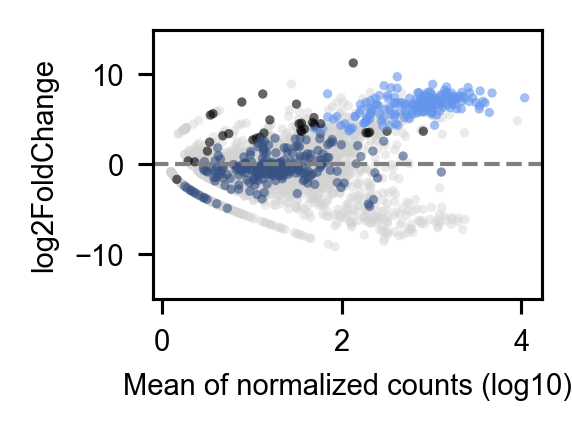

######################
4.302739606430251
######################
Log2 fold change & Wald test p-value: condition ylq-tetramer vs baseline
                           baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                        
2_16_B10_21_GLCTLVAML   2356.463185       -6.143016  0.272816 -38.288696   
2_16_B9_20_GLCTLVAML    2218.415849       -7.245340  0.403891 -28.592084   
2_16_C5_28_GLCTLVAML    1960.155507       -6.381420  0.278084 -38.420674   
2_15_G14_169_GLCTLVAML  1980.535091       -5.968226  0.321466 -31.950435   
2_16_C12_35_GLCTLVAML   1674.243185       -6.122957  0.471370 -22.117860   
...                             ...             ...       ...        ...   
2_10_F11_70_NLVPMVATV      0.702861        3.774407  4.295383  -0.123000   
2_18_A21_104_SWMESEFRV     0.702861        3.774407  4.295383  -0.123000   
2_11_E2_49_SPRWYFYYL       0.702861        3.774407  4.295383  -0.123000   
2_13_F5_64_CINGVCWTV       

Running Wald tests...
... done in 0.18 seconds.



color
lightgrey         3052
cornflowerblue     426
Name: count, dtype: int64
YLQPRTFLL ylq-tetramer
460 not top 10 epitopes
Processing condition: ylq-tetramer_neg, threshold: 0.07347520161544423
color
lightgrey         3247
cornflowerblue     231
Name: count, dtype: int64
YLQPRTFLL ylq-tetramer
Processing condition: glc-tetramer


Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.31 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.29 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Running Wald tests...


[1.89569974 1.7805991  1.51178538 0.63295939 0.94850488 0.40408907]
Log2 fold change & Wald test p-value: condition glc-tetramer vs baseline
                           baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                        
2_16_B10_21_GLCTLVAML   2356.463185        6.143027  0.272675  22.528749   
2_16_B9_20_GLCTLVAML    2218.415849        7.245140  0.403190  17.969525   
2_16_C5_28_GLCTLVAML    1960.155507        6.381416  0.277974  22.956873   
2_15_G14_169_GLCTLVAML  1980.535091        5.968237  0.321203  18.580910   
2_16_C12_35_GLCTLVAML   1674.243185        6.122980  0.470659  13.009374   
...                             ...             ...       ...        ...   
2_10_F11_70_NLVPMVATV      0.702861       -3.774418  4.295394   0.000000   
2_18_A21_104_SWMESEFRV     0.702861       -3.774418  4.295394   0.000000   
2_11_E2_49_SPRWYFYYL       0.702861       -3.774418  4.295394   0.000000   
2_13_F5_64_CINGVCWTV   

... done in 0.14 seconds.



color
lightgrey    3284
indianred     194
Name: count, dtype: int64
GLCTLVAML glc-tetramer
460 not top 10 epitopes
Processing condition: glc-tetramer_pos, threshold: 0.00010915759707790657
color
lightgrey    3361
indianred     117
Name: count, dtype: int64
GLCTLVAML glc-tetramer


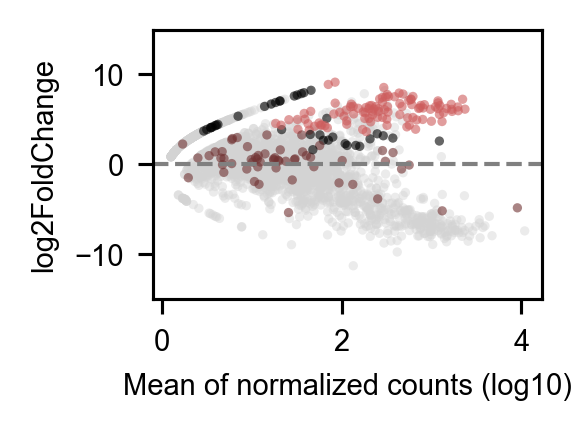

######################
3.8975428627810556
######################


Running Wald tests...
... done in 0.30 seconds.



Log2 fold change & Wald test p-value: condition glc-tetramer vs baseline
                           baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                       
2_16_B10_21_GLCTLVAML   2356.463185        6.143027  0.272675  0.000000   
2_16_B9_20_GLCTLVAML    2218.415849        7.245140  0.403190  0.000000   
2_16_C5_28_GLCTLVAML    1960.155507        6.381416  0.277974  0.000000   
2_15_G14_169_GLCTLVAML  1980.535091        5.968237  0.321203  0.000000   
2_16_C12_35_GLCTLVAML   1674.243185        6.122980  0.470659  0.000000   
...                             ...             ...       ...       ...   
2_10_F11_70_NLVPMVATV      0.702861       -3.774418  4.295394 -1.786090   
2_18_A21_104_SWMESEFRV     0.702861       -3.774418  4.295394 -1.786090   
2_11_E2_49_SPRWYFYYL       0.702861       -3.774418  4.295394 -1.786090   
2_13_F5_64_CINGVCWTV       0.527145       -3.407261  4.321870 -1.690195   
1_1_G19_174_GILGFVFTL      

In [ ]:
sig_hits_dict_single_comp = {}
sig_hits_dict_single_comp_dfs = {}
threshold_dict = {}
set_stats = {}
lfc_dict = {}

new_df = pd.DataFrame()
condition_keys = [key for key in run_df_all_dict.keys() if key.split('_')[0] in condition_list]
new_df = pd.concat([run_df_all_dict[key] for key in condition_keys])

counts_df = new_df.copy() # dont add baseline
counts_df = counts_df.fillna(0)
counts_df = counts_df.sort_index()
for plot_type in [
    # 'tetramer_only_hits',
                  'val-non-val-ambig',
                #   'all',
                   ]:
    for condition_name in condition_list:
        print(f'Processing condition: {condition_name}')
        if condition_name == 'spr':
            continue
        
        meta_data = {name_long : name_long.split('_')[0] for name_long in counts_df.index}
        meta_data_df = pd.DataFrame(meta_data, index=['condition']).T.reset_index()
        meta_data_df.columns = ['run', 'condition']
        meta_data_df.index = meta_data_df['run']
        metadata = meta_data_df
        metadata['screen_day'] = [run_sets[run[0:3]] for run in counts_df.index]
        metadata = metadata.sort_index()
        # if condition column is not  condition_name, then replace with "baseline"
        metadata.loc[metadata['condition'] != condition_name, 'condition'] = 'baseline'
    
        ### DESEQ2 params
        SAVE = False
        min_n_reads = 0
        ### Data filtering
        samples_to_keep = ~metadata.condition.isna()
        counts_df = counts_df.loc[samples_to_keep]
        metadata = metadata.loc[samples_to_keep]
        # Filter out genes with less than min_n_reads
        genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= min_n_reads]
        counts_df = counts_df[genes_to_keep]
        # Run DESeq2
        inference = DefaultInference(n_cpus=8)

        control_genes = [gene if gene.split('_')[-1] not in all_epitopes else None for gene in counts_df.columns]
        # remove None
        control_genes = [gene for gene in control_genes if gene is not None]


        dds = DeseqDataSet(
            counts=counts_df,
            metadata=metadata,
            refit_cooks=False,
            inference=inference,
            # design="~ screen_day + condition",  
            # control_genes=control_genes
        )
        dds.deseq2()
        print(dds.obsm["size_factors"])


        contrast = ["condition", condition_name, "baseline"]

        
        
        results_df = pd.DataFrame()
        for side in ['pos','neg',]:
            condition_name_save = condition_name + '_' + side

            if side == 'pos':
                lfc_null = 0 
            else:
                
                hits_pos = results_df[results_df['color'] == name_color_dict[short_to_long_epi[condition_name]]]
                hits_pos = hits_pos.index
                mean_lfc = results_df[results_df.index.isin(hits_pos)]['log2FoldChange'].mean()
                lfc_dict[condition_name] = mean_lfc
                lfc_null = mean_lfc*0.66
                print('######################')
                print(lfc_null)
                print('######################')

            alt_hypothesis = 'greater' if side == 'pos' else 'less'
            side_percentage = 5 

            ds = DeseqStats(dds, 
                        contrast=contrast, 
                        cooks_filter=False,
                        independent_filter=False,
                        inference=inference,
                        )
            ds.summary(lfc_null=lfc_null, alt_hypothesis=alt_hypothesis)
            for shrink_no_shrink in [False,]: #True]:
                print(f'Running DESeq2 for condition: {condition_name}, shrink_no_shrink: {shrink_no_shrink}')
                if shrink_no_shrink:
                    ds.lfc_shrink(coeff=f'condition[T.{condition_name}]')
                else:
                    pass



                def get_significance_binary_color(padj, threshold, color):
                    if padj < threshold:
                        return color
                    return 'lightgrey'
                
                results_df = ds.results_df.copy()
                results_df['baseMean'] = results_df['baseMean'].apply(lambda x: np.log10(x + 1))
                results_df['color'] = 'lightgrey'
                
                results_df['epitope_split'] = results_df.index.str.split('_').str[-1]
                no_hit_df = results_df[~results_df['epitope_split'].isin(all_epitopes)]
                no_hit_df = no_hit_df.reset_index()
                no_hit_df['no_hit_ids'] = no_hit_df['TCR']

                not_top_10 = results_df[results_df.index.isin(no_hit_df['no_hit_ids'].values)]
                if side == 'neg':
                    red_line_y = np.sort(not_top_10['padj'])[int(len(not_top_10) * (100 - side_percentage) / 100)]
                else:
                    red_line_y = np.sort(not_top_10['padj'])[int(len(not_top_10) * (side_percentage / 100))]
                threshold_non_val = red_line_y
                threshold_dict[condition_name_save] = threshold_non_val
                padj_thresholds = [
                    100, 
                    threshold_non_val]
                for threshold in padj_thresholds:
                    print(len(not_top_10), 'not top 10 epitopes')
                    print(f'Processing condition: {condition_name_save}, threshold: {threshold}')

                    for index, row in results_df.iterrows():
                        epi_name = index.split('_')[-1]
                        if epi_name == short_to_long_epi[condition_name]:
                            if epi_name in name_color_dict.keys():
                                results_df.loc[index, 'color'] = get_significance_binary_color(row['padj'], threshold, name_color_dict[epi_name])

                        elif epi_name not in all_epitopes:
                            results_df.loc[index, 'color'] = 'black'

                        if index in no_hit_df['no_hit_ids'].values:
                            results_df.loc[index, 'color'] = 'lightgrey'

                    if threshold < 1:
                        significant_hits = results_df['color'] != 'lightgrey'
                        sig_hits_dict_single_comp[condition_name_save] = results_df.loc[significant_hits].copy()

                    if threshold == 100:
                        save_name_stats = condition_name + '_all'
                    else:
                        save_name_stats = condition_name_save


                        set_stats[save_name_stats] = {
                            'red_line_y': red_line_y,
                            'threshold_non_val': threshold_non_val,
                            'condition_name': condition_name,
                            'side': side,
                            'color': name_color_dict.get(short_to_long_epi[condition_name], 'lightgrey'),
                            'count' : results_df['color'].value_counts().get(name_color_dict.get(short_to_long_epi[condition_name], 'lightgrey'), 0),
                            'ids': results_df[results_df['color'] == name_color_dict.get(short_to_long_epi[condition_name], 'lightgrey')].index.tolist(),
                            'any_above_thresh': results_df[results_df['padj'] < threshold].index.tolist(),
                            'hits_annotated_above_thresh': results_df[results_df.index.str.contains(short_to_long_epi[condition_name]) & (results_df['padj'] < threshold)].index.tolist(),
                            'hits_not_annotated_above_thresh': results_df[~results_df.index.str.contains(short_to_long_epi[condition_name]) & (results_df['padj'] < threshold)].index.tolist(),
                            'full_df': results_df.copy(),
                        }
                    print(results_df['color'].value_counts())
                    print(short_to_long_epi[condition_name], condition_name)


                    if 'pos' in condition_name_save:
                        sig_hits_dict_single_comp_dfs[condition_name] = results_df.copy()


                    if plot_type == 'tetramer_only_hits':
                        tetramer_only = ["1_4_G17_172_YLQPRTFLL", "1_6_G14_169_YLQPRTFLL", "1_6_A24_107_YLQPRTFLL"]
                        if side == 'pos' and threshold != 100:
                            for index, row in results_df.iterrows():
                                if "YLQPRTFLL" in index:
                                        results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]
                                if index in tetramer_only:
                                    results_df.loc[index, 'color'] = 'black'
                        else:
                            continue
                    elif plot_type == 'val-non-val-ambig':
                        if side == 'pos' and threshold != 100:
                            results_df['color'] = 'lightgrey'
                            for index, row in results_df.iterrows():
                                if index in stats_data_allv1_tetramer[short_to_long_epi[condition_name]]['pos_ids']:
                                    results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]
                                elif index in stats_data_allv1_tetramer[short_to_long_epi[condition_name]]['neg_ids']:
                                    results_df.loc[index, 'color'] = name_color_dict_darker[short_to_long_epi[condition_name]]
                                elif index in stats_data_allv1_tetramer[short_to_long_epi[condition_name]]['ambiguous_ids']:
                                    results_df.loc[index, 'color'] = 'black'
                                elif index in stats_data_allv1_tetramer[short_to_long_epi[condition_name]]['intersection_ids']:
                                    results_df.loc[index, 'color'] = 'black'
                                else:
                                    results_df.loc[index, 'color'] = 'lightgrey'
                        else:
                            continue

                    plt.figure(figsize=(figsize[0], figsize[1]))

                    grey_mask = results_df['color'] == 'lightgrey'
                    grey_df = results_df[grey_mask].sample(frac=1, random_state=None)
                    plt.scatter(grey_df['baseMean'], grey_df['log2FoldChange'],
                                color='lightgrey', alpha=background_alpha,
                                s=dotsize, edgecolor='None')
                    other_df = results_df[~grey_mask].sample(frac=1, random_state=None)

                    for _, row in other_df.iterrows():
                        color = row['color']

                        if plot_type == 'arrayed-pilot' and color != 'black':
                            alpha = 1.0
                            dotsize_curr = dotsize
                        elif plot_type == 'tetramer_only_hits' and color == 'black':
                            alpha = 1.0
                            dotsize_curr = 10
                        elif plot_type == 'pos-neg-ambig':
                            alpha = color_alpha
                            dotsize_curr = dotsize
                        else:
                            alpha = color_alpha
                            dotsize_curr = dotsize

                        plt.scatter(row['baseMean'], row['log2FoldChange'],
                                    color=color, alpha=alpha,
                                    s=dotsize_curr, edgecolor='None')
                    plt.ylim(-15, 15)
                    plt.xlabel('Mean of normalized counts (log10)', fontsize=fontsize_axes)
                    plt.ylabel('log2FoldChange', fontsize=fontsize_axes)

                    legend_labels = []
                    for color in color_list:
                        count = results_df[results_df['color'] == color].shape[0]
                        if color in color_name_dict:
                            label = f"{color_name_dict[color]} ({count})"
                        else:
                            label = f"Other ({count})"
                        legend_labels.append(label)
                    plt.axhline(0, color='grey', linestyle='--', linewidth=1)


                    # if threshold == 100 and 'pos' in condition_name_save:
                    #     pass
                    # else:
                    #     plt.savefig(f'saved_plots_all-v-1-tetramer/{condition_name_save}_MA_{threshold}.pdf', bbox_inches='tight', dpi=300)
                    if SAVE_DROPBOX:
                        plt.tight_layout()
                        if plot_type == 'all':
                            plt.savefig(out_path_dropbox + f'MA_{condition_name}_{epitope1_short}_{epitope2_short}_significance_binary_{threshold}.pdf', 
                                        bbox_inches='tight',
                                        dpi=300)
                        else:
                            plt.savefig(out_path_dropbox + f'{plot_type}_MA_{condition_name}_{epitope1_short}_{epitope2_short}.pdf', 
                                        bbox_inches='tight',
                                        dpi=300)
                    
                    plt.show()
                    plt.close()    


In [16]:
for name, lfc in lfc_dict.items():
    print(f"Condition: {name}, LFC: {lfc}, lfc_null: {lfc*0.66}")

Condition: ylq-tetramer, LFC: 6.519302433985229, lfc_null: 4.302739606430251
Condition: glc-tetramer, LFC: 5.90536797391069, lfc_null: 3.8975428627810556


In [ ]:
experiment_set_stats = {}

for experiment_name in set([name.split('_')[0] for name in set_stats.keys()]):

    # for pos and neg get the intersection of the ids
    pos_ids = set_stats.get(f"{experiment_name}_pos", {}).get('hits_annotated_above_thresh', [])
    neg_ids = set_stats.get(f"{experiment_name}_neg", {}).get('hits_annotated_above_thresh', [])
    all_ids = set_stats.get(f"{experiment_name}_all", {}).get('hits_annotated_above_thresh', [])
    other_hits = set_stats.get(f"{experiment_name}_pos", {}).get('hits_not_annotated_above_thresh', [])
    
    intersection_ids = set(pos_ids).intersection(set(neg_ids))
    # combine pos and neg unique ids and get the difference with all_ids
    unique_pos_neg_ids = set(pos_ids).union(set(neg_ids))
    ambiguous_ids = set(all_ids).difference(unique_pos_neg_ids)
    # remove intersection_ids from pos and neg ids
    pos_ids = [idx for idx in pos_ids if idx not in intersection_ids]
    neg_ids = [idx for idx in neg_ids if idx not in intersection_ids]
    # remove ambiguous_ids from pos and neg ids
    pos_ids = [idx for idx in pos_ids if idx not in ambiguous_ids]
    neg_ids = [idx for idx in neg_ids if idx not in ambiguous_ids]

    print(f"Experiment: {experiment_name}\n\t Intersection IDs: {len(intersection_ids)}, Ambiguous IDs: {len(ambiguous_ids)}, \n\t pos: {len(pos_ids)}, neg: {len(neg_ids)}, all: {len(all_ids)}")
    print(f"\t threshold pos: {set_stats.get(f'{experiment_name}_pos', {}).get('threshold_non_val', 'N/A')}, threshold neg: {set_stats.get(f'{experiment_name}_neg', {}).get('threshold_non_val', 'N/A')}")
    print(f"\t Other hits (not annotated for this epitope but above threshold): {len(other_hits)}")
    
    
    
    other_hits_epi = [idx.split('_')[-1] for idx in other_hits]
    other_hits_counts = pd.Series(other_hits_epi).value_counts()


    experiment_set_stats[short_to_long_epi[experiment_name]] = {
        'intersection_ids': list(intersection_ids),
        'ambiguous_ids': list(ambiguous_ids),
        'pos_ids': list(pos_ids),
        'neg_ids': list(neg_ids),
        'all_ids': list(all_ids),
        'not_annotated_for_this_epitope_but_above_threshold': list(other_hits),
        'threshold_pos': set_stats.get(f"{experiment_name}_pos", {}).get('threshold_non_val', 'N/A'),
        'threshold_neg': set_stats.get(f"{experiment_name}_neg", {}).get('threshold_non_val', 'N/A'),
    }

print()
all_other_hits = []
for name, lists in experiment_set_stats.items():  
    for idx in lists['not_annotated_for_this_epitope_but_above_threshold']:
        all_other_hits.append(idx)

print(len(all_other_hits), 'all other hits')
print(len(set(all_other_hits)), 'unique other hits')

# get overlap with hits
all_hits = []
for name, lists in experiment_set_stats.items():
    all_hits.extend(lists['pos_ids'])

print(len(all_hits), 'all hits')
print(len(set(all_hits)), 'unique hits')
print(len(set(all_other_hits).intersection(set(all_hits))), 'overlap with hits')
print(len(set(all_other_hits).difference(set(all_hits))), 'other hits not in hits')


# save the experiment_set_stats
# import json
# with open('saved_dfs/experiment_set_stats_tetramer_all-v-1.json', 'w') as f:
#     json.dump(experiment_set_stats, f, indent=4)    

Experiment: ylq-tetramer
	 Intersection IDs: 5, Ambiguous IDs: 0, 
	 pos: 167, neg: 226, all: 0
	 threshold pos: 8.544841948021151e-16, threshold neg: 0.08490624332613571
	 Other hits (not annotated for this epitope but above threshold): 126
Experiment: glc-tetramer
	 Intersection IDs: 15, Ambiguous IDs: 0, 
	 pos: 102, neg: 56, all: 0
	 threshold pos: 0.00010915759707790657, threshold neg: 0.4663788394393289
	 Other hits (not annotated for this epitope but above threshold): 133

259 all other hits
259 unique other hits
269 all hits
269 unique hits
0 overlap with hits
259 other hits not in hits


In [44]:
# all_other_hits to json

# with open('saved_dfs/hits_not_annotated_to_cognate_tetramer_all-v-1.json', 'w') as f:
    # json.dump(list(set(all_other_hits)), f, indent=4)

In [ ]:
import pandas as pd

with open("/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/rebuttal_data_analysis/old_tcrvdb_1may2025/hits_pre-print/ylq_hits_p1e-05", 'r') as f:
    set_ylq_old = set([line.strip() for line in f.readlines()])

with open("/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/rebuttal_data_analysis/old_tcrvdb_1may2025/hits_pre-print/glc_hits_p1e-05", 'r') as f:
    set_glc_old = set([line.strip() for line in f.readlines()])


In [ ]:
# read /Users/b.kwee/surfdrive/Bjorn/12_validate_all_tcrs_deseq2/deseq2/saved_dfs/experiment_set_stats_all-v-1.json
import json

with open('experiment_set_stats_all-v-1.json') as f:
    experiment_stats_functional = json.load(f)
ylq_pos = experiment_stats_functional['YLQPRTFLL']['pos_ids'] 
glc_pos = experiment_stats_functional['GLCTLVAML']['pos_ids'] 

ylq_ambig = experiment_stats_functional['YLQPRTFLL']['ambiguous_ids'] + experiment_stats_functional['YLQPRTFLL']['intersection_ids']
glc_ambig = experiment_stats_functional['GLCTLVAML']['ambiguous_ids'] + experiment_stats_functional['GLCTLVAML']['intersection_ids']

ylq_neg = experiment_stats_functional['YLQPRTFLL']['neg_ids']
glc_neg = experiment_stats_functional['GLCTLVAML']['neg_ids']

### make confusion matrix functional vs tetramer

In [54]:
ylq_pos_tetra = experiment_set_stats['YLQPRTFLL']['pos_ids']
ylq_neg_tetra = experiment_set_stats['YLQPRTFLL']['neg_ids']
glc_pos_tetra = experiment_set_stats['GLCTLVAML']['pos_ids']
glc_neg_tetra = experiment_set_stats['GLCTLVAML']['neg_ids']

ylq_ambig_tetra = experiment_set_stats['YLQPRTFLL']['ambiguous_ids'] + experiment_set_stats['YLQPRTFLL']['intersection_ids']
glc_ambig_tetra = experiment_set_stats['GLCTLVAML']['ambiguous_ids'] + experiment_set_stats['GLCTLVAML']['intersection_ids']

In [ ]:
intersect_pos = set(ylq_pos).intersection(set(ylq_pos_tetra))
print(f"YLQ pos overlap functional and tetramer: {len(intersect_pos)} / {len(ylq_pos)} functional, {len(ylq_pos_tetra)} tetramer")
intersect_neg = set(ylq_neg).intersection(set(ylq_neg_tetra))
print(f"YLQ neg overlap functional and tetramer: {len(intersect_neg)} / {len(ylq_neg)} functional, {len(ylq_neg_tetra)} tetramer")


YLQ pos overlap functional and tetramer: 139 / 158 functional, 167 tetramer
YLQ neg overlap functional and tetramer: 206 / 231 functional, 226 tetramer


In [59]:
intersect_pos_glc = set(glc_pos).intersection(set(glc_pos_tetra))
print(f"GLC pos overlap functional and tetramer: {len(intersect_pos_glc)} / {len(glc_pos)} functional, {len(glc_pos_tetra)} tetramer")
intersect_neg_glc = set(glc_neg).intersection(set(glc_neg_tetra))
print(f"GLC neg overlap functional and tetramer: {len(intersect_neg_glc)} / {len(glc_neg)} functional, {len(glc_neg_tetra)} tetramer    ")

GLC pos overlap functional and tetramer: 83 / 110 functional, 102 tetramer
GLC neg overlap functional and tetramer: 39 / 59 functional, 56 tetramer    


In [60]:
intersect_pos_tetra_neg_func = set(ylq_pos_tetra).intersection(set(ylq_neg))
print(f"YLQ pos tetramer and neg functional overlap: {len(intersect_pos_tetra_neg_func)}")
intersect_pos_tetra_neg_func_glc = set(glc_pos_tetra).intersection(set(glc_neg))
print(f"GLC pos tetramer and neg functional overlap: {len(intersect_pos_tetra_neg_func_glc)}")

YLQ pos tetramer and neg functional overlap: 13
GLC pos tetramer and neg functional overlap: 7


In [61]:
intersect_neg_tetra_pos_func = set(ylq_neg_tetra).intersection(set(ylq_pos))
print(f"YLQ neg tetramer and pos functional overlap: {len(intersect_neg_tetra_pos_func)}")
intersect_neg_tetra_pos_func_glc = set(glc_neg_tetra).intersection(set(glc_pos))
print(f"GLC neg tetramer and pos functional overlap: {len(intersect_neg_tetra_pos_func_glc)}")


YLQ neg tetramer and pos functional overlap: 5
GLC neg tetramer and pos functional overlap: 10


Exception ignored in: <function ResourceTracker.__del__ at 0x10445b4c0>
Traceback (most recent call last):
  File "/Users/b.kwee/miniconda3/envs/pydeseq2_cp/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/b.kwee/miniconda3/envs/pydeseq2_cp/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/b.kwee/miniconda3/envs/pydeseq2_cp/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104f5b4c0>
Traceback (most recent call last):
  File "/Users/b.kwee/miniconda3/envs/pydeseq2_cp/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/b.kwee/miniconda3/envs/pydeseq2_cp/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/b.kwee/miniconda3/envs/pydeseq2_cp/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _sto

In [56]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Define label order
labels = ["pos", "ambig", "neg"]

for epi in ['YLQPRTFLL', 'GLCTLVAML']:
    if epi == 'YLQPRTFLL':
        subset_epi_f = ylq_functional[ylq_functional['epitope_split'] == epi].copy()
        subset_epi_tetra = ylq_tetramer_ylq_only[ylq_tetramer_ylq_only['epitope_split'] == epi].copy()
        
        pos_ids, ambig_ids, neg_ids = ylq_pos, ylq_ambig, ylq_neg
        pos_t, ambig_t, neg_t = ylq_pos_tetra, ylq_ambig_tetra, ylq_neg_tetra

    else:
        subset_epi_f = glc_functional[glc_functional['epitope_split'] == epi].copy()
        subset_epi_tetra = glc_tetramer_glc_only[glc_tetramer_glc_only['epitope_split'] == epi].copy()
        
        pos_ids, ambig_ids, neg_ids = glc_pos, glc_ambig, glc_neg
        pos_t, ambig_t, neg_t = glc_pos_tetra, glc_ambig_tetra, glc_neg_tetra

    # Combine all relevant IDs
    all_ids = set(subset_epi_f['TCR']).intersection(set(subset_epi_tetra.index))

    # Assign categories based on ID sets
    def get_label(tcr_id, pos_set, ambig_set, neg_set):
        if tcr_id in pos_set:
            return "pos"
        elif tcr_id in ambig_set:
            return "ambig"
        elif tcr_id in neg_set:
            return "neg"
        else:
            return None

    # Create comparison DataFrame
    compare_df = pd.DataFrame({
        "TCR": list(all_ids),
        "functional_label": [get_label(t, pos_ids, ambig_ids, neg_ids) for t in all_ids],
        "tetramer_label": [get_label(t, pos_t, ambig_t, neg_t) for t in all_ids],
    }).dropna()

    # Create confusion matrix
    cm = pd.DataFrame(
        confusion_matrix(compare_df["functional_label"], compare_df["tetramer_label"], labels=labels),
        index=[f"functional_{l}" for l in labels],
        columns=[f"tetramer_{l}" for l in labels]
    )

    print(f"\nConfusion matrix for {epi}:")
    print(cm)



Confusion matrix for YLQPRTFLL:
                  tetramer_pos  tetramer_ambig  tetramer_neg
functional_pos             139               3             5
functional_ambig            15               1            15
functional_neg              13               1           206

Confusion matrix for GLCTLVAML:
                  tetramer_pos  tetramer_ambig  tetramer_neg
functional_pos              83               9            10
functional_ambig            12               1             7
functional_neg               7               5            39
